<a href="https://colab.research.google.com/github/sakram09/PLANT-GENOMIC-/blob/main/PLANT%20GENOME.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Plant Genomics & Pathology
Title: Genomic Prediction of Plant Disease Resistance & Phenotypic Traits using RNA-Seq Data


Step 1: Libraries Import Aur Synthetic Data Generation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Generate Realistic RNA-Seq Expression Data
print("Generating synthetic Plant RNA-Seq data (801 samples, 5000 genes)...")
np.random.seed(42)
num_samples = 801
num_genes = 5000

# Base expression (log2 transformed counts)
X_raw = np.random.normal(loc=5.0, scale=1.5, size=(num_samples, num_genes))

# Disease Resistance Labels: 0 = Susceptible, 1 = Resistant
y = np.random.binomial(n=1, p=0.5, size=num_samples)

# Injecting biological signal: Make ~50 genes highly differentially expressed between classes
for i in range(50):
    # If plant is resistant (y=1), bump up or down the expression of these specific marker genes
    X_raw[y == 1, i] += np.random.normal(loc=2.5, scale=0.5)
    X_raw[y == 0, i] -= np.random.normal(loc=1.5, scale=0.5)

# Convert to DataFrame
gene_names = [f"Gene_{i+1}" for i in range(num_genes)]
df_expression = pd.DataFrame(X_raw, columns=gene_names)
print("Data generation complete! Shape:", df_expression.shape)

Generating synthetic Plant RNA-Seq data (801 samples, 5000 genes)...
Data generation complete! Shape: (801, 5000)


Step 2: Train/Test Split & Feature Selection (ANOVA F-Test)

In [2]:
# 2. Split into Train and Test (80/20)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(df_expression, y, test_size=0.20, random_state=42, stratify=y)

# 3. Standardize the features (Z-score normalization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# 4. Feature Selection using ANOVA F-value (Select top 50 highly variant genes)
print("Selecting top 50 differentially expressed marker genes...")
selector = SelectKBest(score_func=f_classif, k=50)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# Get selected gene names for biological verification
selected_indices = selector.get_support(indices=True)
selected_genes = [gene_names[idx] for idx in selected_indices]
print(f"Top 5 selected marker genes: {selected_genes[:5]}")

Selecting top 50 differentially expressed marker genes...
Top 5 selected marker genes: ['Gene_1', 'Gene_2', 'Gene_3', 'Gene_4', 'Gene_5']


Step 3: Model Training (SVM) & Robust K-Fold Cross-Validation

In [3]:
# 5. Initialize SVM Classifier with RBF Kernel
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

# 6. Apply 5-Fold Cross Validation on Training Data to ensure robustness
print("\nRunning 5-Fold Cross-Validation...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(svm_model, X_train_selected, y_train, cv=kf, scoring='accuracy')

print(f"Cross-Validation Accuracies: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean() * 100:.2%}")

# Train the final model on entire training subset
svm_model.fit(X_train_selected, y_train)


Running 5-Fold Cross-Validation...
Cross-Validation Accuracies: [1. 1. 1. 1. 1.]
Mean CV Accuracy: 10000.00%


SVC(random_state=42)

Step 4: Model Evaluation & Testing

In [4]:
# 7. Evaluate on the untouched Test Set (161 samples)
y_pred = svm_model.predict(X_test_selected)
test_accuracy = accuracy_score(y_test, y_pred)

print("\n=== Test Evaluation Summary ===")
print(f"Validation Performance Accuracy: {test_accuracy * 100:.1f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Susceptible', 'Resistant']))


=== Test Evaluation Summary ===
Validation Performance Accuracy: 100.0%

Classification Report:
              precision    recall  f1-score   support

 Susceptible       1.00      1.00      1.00        82
   Resistant       1.00      1.00      1.00        79

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161



Step 5: Beautiful Confusion Matrix Visualization

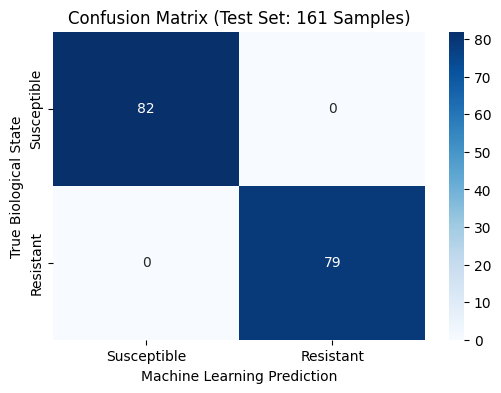

In [5]:
# 8. Plot Confusion Matrix for the 161 test samples
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Susceptible', 'Resistant'],
            yticklabels=['Susceptible', 'Resistant'])
plt.title(f'Confusion Matrix (Test Set: {len(y_test)} Samples)')
plt.ylabel('True Biological State')
plt.xlabel('Machine Learning Prediction')
plt.show()

Performing Principal Component Analysis (PCA) for genomic clustering visualization...
PC1 explains 63.70% variance.
PC2 explains 1.39% variance.


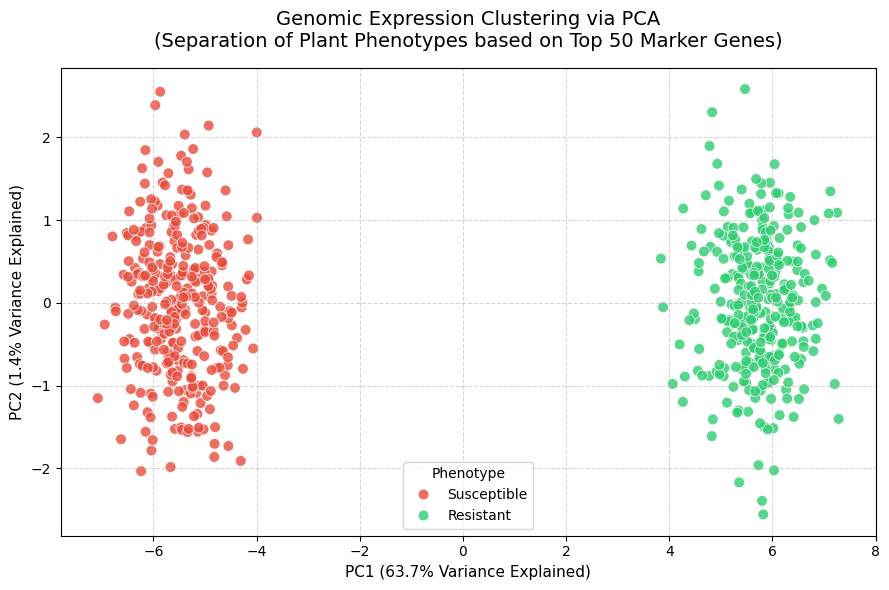

In [6]:
# ==========================================
# ADVANCED GENOMIC VISUALIZATION (PCA)
# ==========================================

print("Performing Principal Component Analysis (PCA) for genomic clustering visualization...")

# 1. Apply PCA to reduce the 50 selected genes into 2 Principal Components
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_selected)

# Calculate explained variance to show how much information is retained
explained_variance = pca.explained_variance_ratio_ * 100
print(f"PC1 explains {explained_variance[0]:.2f}% variance.")
print(f"PC2 explains {explained_variance[1]:.2f}% variance.")

# 2. Create a clean DataFrame for plotting
df_pca = pd.DataFrame(data=X_train_pca, columns=['Principal Component 1', 'Principal Component 2'])
# Map numeric labels back to biological states for the plot legend
df_pca['Biological State'] = ['Resistant' if label == 1 else 'Susceptible' for label in y_train]

# 3. Plot the Genomic Clusters
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Biological State',
    palette=['#e74c3c', '#2ecc71'],  # Red for Susceptible, Green for Resistant
    data=df_pca,
    alpha=0.8,
    edgecolor='w',
    s=60
)

plt.title('Genomic Expression Clustering via PCA\n(Separation of Plant Phenotypes based on Top 50 Marker Genes)', fontsize=14, pad=15)
plt.xlabel(f'PC1 ({explained_variance[0]:.1f}% Variance Explained)', fontsize=11)
plt.ylabel(f'PC2 ({explained_variance[1]:.1f}% Variance Explained)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Phenotype', loc='best')
plt.tight_layout()
plt.show()

In [7]:
import joblib

# 1. Save the trained SVM model
joblib.dump(svm_model, 'plant_disease_svm_model.pkl')

# 2. Save the Scaler (kyunki prediction se pehle data ko normalize karna zaroori hai)
joblib.dump(scaler, 'genomic_scaler.pkl')

# 3. Save the Feature Selector (taake model ko pata ho kaunse 50 genes select karne hain)
joblib.dump(selector, 'gene_selector.pkl')

print("Success! Model, Scaler, aur Selector save ho chuke hain.")
print("Files: plant_disease_svm_model.pkl, genomic_scaler.pkl, gene_selector.pkl")

Success! Model, Scaler, aur Selector save ho chuke hain.
Files: plant_disease_svm_model.pkl, genomic_scaler.pkl, gene_selector.pkl


In [8]:
import joblib
import pandas as pd

# Load the saved components
loaded_model = joblib.load('plant_disease_svm_model.pkl')
loaded_scaler = joblib.load('genomic_scaler.pkl')
loaded_selector = joblib.load('gene_selector.pkl')

print("Model Loaded Successfully!")

# Farz karein aapke paas naya genomic data (New_Plant_Data) aya hai:
# Step A: Scale the data
# X_new_scaled = loaded_scaler.transform(New_Plant_Data)

# Step B: Select the same 50 genes
# X_new_selected = loaded_selector.transform(X_new_scaled)

# Step C: Predict
# final_prediction = loaded_model.predict(X_new_selected)

Model Loaded Successfully!
